Enter WRDS username:  user_lychee
Enter WRDS password:  asdfghjkl060405


Loading library list...
Done
Revenue (Billions USD)
fyear    2019    2020    2021    2022    2023    2024
tic                                                  
AAPL   260.17  274.52  365.82  394.33  383.28  391.04
AMZN   280.52  386.06  469.82  513.98  574.78  637.96
GOOGL  161.86  182.53  257.64  282.84  307.39  350.02
MSFT   125.84  143.01  168.09  198.27  211.92  245.12

Net Income (Billions USD)
fyear   2019   2020   2021   2022   2023    2024
tic                                             
AAPL   55.26  57.41  94.68   99.8   97.0   93.74
AMZN   11.59  21.33  33.36  -2.72  30.42   59.25
GOOGL  34.34  40.27  76.03  59.97   73.8  100.12
MSFT   39.24  44.28  61.27  72.74  72.36   88.14

Return on Equity (%)
fyear   2019   2020    2021    2022    2023    2024
tic                                                
AAPL   61.06  87.87  150.07  196.96  156.08  164.59
AMZN   18.67  22.84   24.13   -1.86   15.07   20.72
GOOGL  17.05  18.09   30.22   23.41   26.25   31.09
MSFT   38.35  37.43  

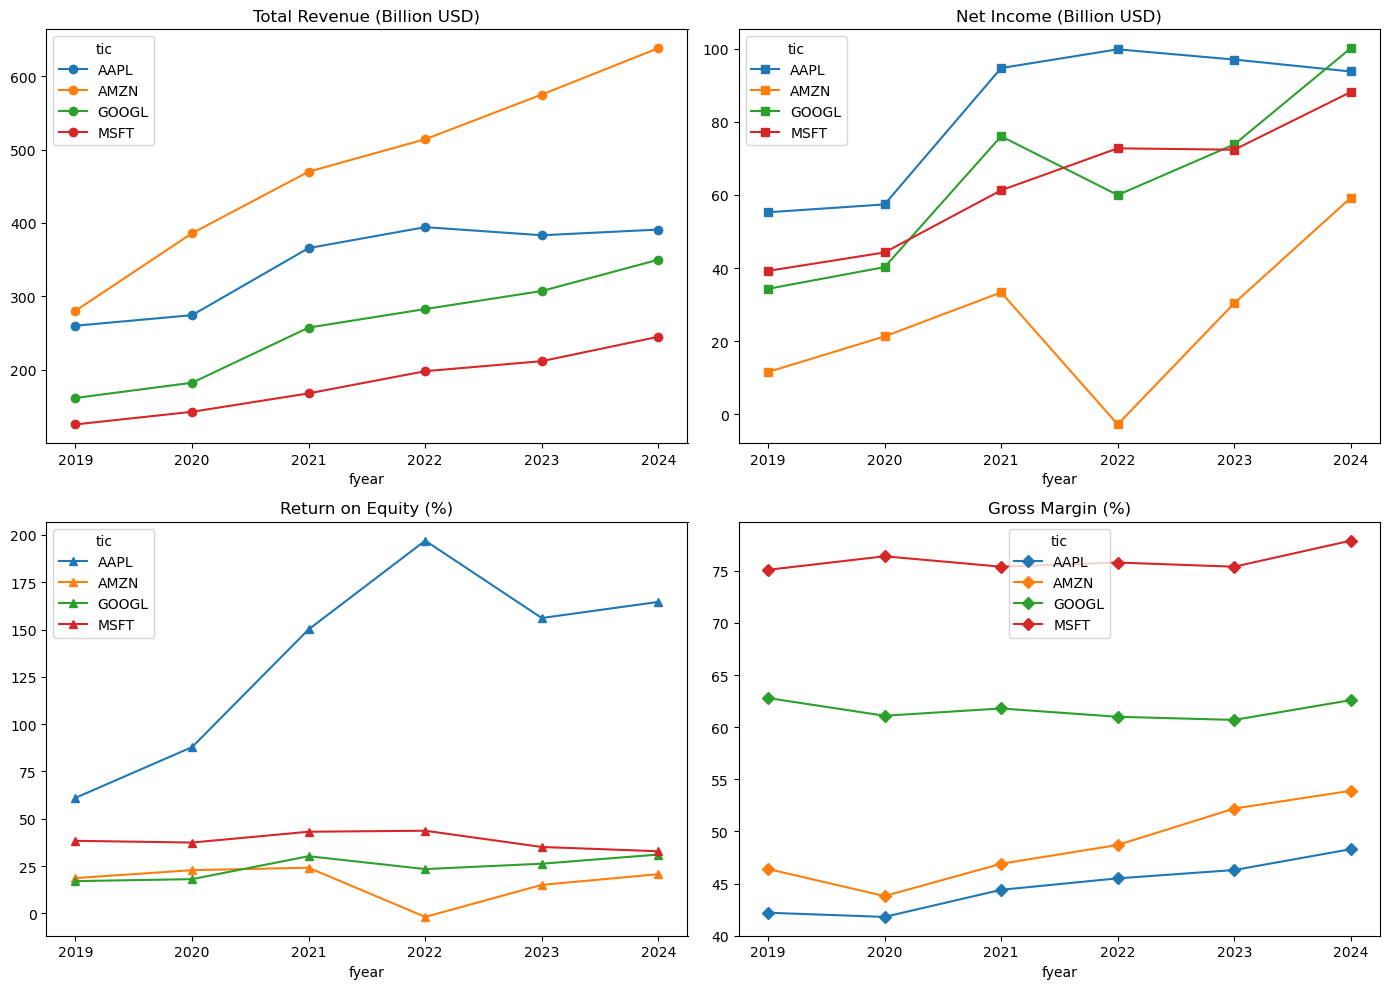

In [2]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

username = input("Enter WRDS username: ")
password = input("Enter WRDS password: ")

conn = wrds.Connection(wrds_username=username, wrds_password=password)

query = """
SELECT tic, conm, fyear, revt, ni, gp, sale, seq, at
FROM comp.funda
WHERE tic IN ('AAPL', 'MSFT', 'GOOGL', 'AMZN')
AND fyear BETWEEN 2019 AND 2024
AND indfmt='INDL' AND datafmt='STD' AND popsrc='D' AND consol='C'
ORDER BY tic, fyear;
"""

df = conn.raw_sql(query)
conn.close()

df = df.dropna()
df['fyear'] = df['fyear'].astype(int)
df['roe'] = (df['ni'] / df['seq']) * 100
df['gross_margin'] = (df['gp'] / df['sale']) * 100
df['revt'] = df['revt'] / 1000
df['ni'] = df['ni'] / 1000

rev_pivot = df.pivot_table(index='tic', columns='fyear', values='revt').round(2)
ni_pivot = df.pivot_table(index='tic', columns='fyear', values='ni').round(2)
roe_pivot = df.pivot_table(index='tic', columns='fyear', values='roe').round(2)
gm_pivot = df.pivot_table(index='tic', columns='fyear', values='gross_margin').round(1)

print("Revenue (Billions USD)")
print(rev_pivot)
print("\nNet Income (Billions USD)")
print(ni_pivot)
print("\nReturn on Equity (%)")
print(roe_pivot)
print("\nGross Margin (%)")
print(gm_pivot)

fig, axes = plt.subplots(2, 2, figsize=(14,10))
rev_pivot.T.plot(ax=axes[0,0], marker='o')
axes[0,0].set_title('Total Revenue (Billion USD)')

ni_pivot.T.plot(ax=axes[0,1], marker='s')
axes[0,1].set_title('Net Income (Billion USD)')

roe_pivot.T.plot(ax=axes[1,0], marker='^')
axes[1,0].set_title('Return on Equity (%)')

gm_pivot.T.plot(ax=axes[1,1], marker='D')
axes[1,1].set_title('Gross Margin (%)')

plt.tight_layout()
plt.savefig('financial_analysis.png', dpi=300)
plt.show()

df.to_csv('tech_giants_financial_data.csv', index=False)
rev_pivot.to_csv('revenue_pivot.csv')
roe_pivot.to_csv('roe_pivot.csv')